In [ ]:
# ! python -m pip install --no-index --find-links=/kaggle/usr/lib/pip_install_permanent/my_packages -r /kaggle/usr/lib/pip_install_permanent/requirements.txt

In [ ]:
# import os

# os.environ['PACKAGE_DIR'] = '/kaggle/usr/lib/pip_install_permanent'

In [1]:
from helper_func import *
# # import helper_functions as hf
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# from spellchecker import SpellChecker

# from tqdm.contrib.concurrent import process_map  # If this import fails, you might need to update tqdm

# import multiprocessing
 
# # Import Packages
# # import shutup; shutup.please()

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import keras_tuner as kt
# import seaborn as sns

# from nltk.corpus import stopwords, wordnet
# from nltk.tokenize import word_tokenize, sent_tokenize
# from nltk import pos_tag, ne_chunk
# from textblob import TextBlob

# from textstat import flesch_reading_ease, smog_index

# import spacy
# from collections import Counter
# from gensim import corpora, models
# import pyLDAvis.gensim as gen
# import pyLDAvis
# import re

# # Machine Learning & Data Preprocessing

# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# # Deep Learning

# from tensorflow.keras import layers
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Gensim
# # from gensim.models import Word2Vec, KeyedVectors

# # Progress bar
# from tqdm import tqdm

# # Keras Tuner
# from keras_tuner.tuners import RandomSearch

# # # Setting logging levels and environment variables
# # tf.get_logger().setLevel(logging.ERROR)
# # os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# from textstat import flesch_reading_ease
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# print('Packages Instaled......')

/home/jack/envs/scoring/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
import pandas as pd

train = pd.read_csv('/home/jack/github/kaggle/scoring/xlnet_hash.csv')
train.drop(columns=['score', 'labels'], inplace=True)

train.head()

,essay_id,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000fe60,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.136665,0.115104,...,0.000000,0.119048,0.000000,0.000000,0.000000,0.023810,0.190476,0.071429,0.000000,0.02381
1,001ab80,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.132327,0.110495,...,0.029130,0.043694,0.014565,0.014565,0.000000,0.014565,0.262167,0.014565,0.000000,0.00000
2,002ba53,dear state senator this is a letter to argue i...,0.059430,0.691130,0.233244,0.014120,0.001189,0.000887,0.132971,0.113607,...,0.000000,0.031758,0.000000,0.000000,0.000000,0.000000,0.381096,0.000000,0.031758,0.00000
3,0033037,the posibilty of a face reconizing computer wo...,0.110127,0.875540,0.012530,0.000799,0.000427,0.000577,0.133904,0.109733,...,0.000000,0.039073,0.000000,0.000000,0.000000,0.000000,0.195366,0.000000,0.000000,0.00000
4,0033bf4,what is the seagoing cowboys progam it was to ...,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,0.133583,0.111408,...,0.019364,0.019364,0.000000,0.019364,0.019364,0.000000,0.096819,0.193637,0.000000,0.00000


In [4]:
hash_cols = [col for col in train.columns if 'hash' in col]

train.drop(columns=hash_cols, inplace=True)

train.head()

,essay_id,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5
0,000fe60,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.136665,0.115104,0.258191,0.112356,0.164195,0.213489
1,001ab80,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.132327,0.110495,0.258206,0.115311,0.163469,0.220192
2,002ba53,dear state senator this is a letter to argue i...,0.059430,0.691130,0.233244,0.014120,0.001189,0.000887,0.132971,0.113607,0.266656,0.112359,0.161093,0.213313
3,0033037,the posibilty of a face reconizing computer wo...,0.110127,0.875540,0.012530,0.000799,0.000427,0.000577,0.133904,0.109733,0.257915,0.112806,0.166446,0.219196
4,0033bf4,what is the seagoing cowboys progam it was to ...,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,0.133583,0.111408,0.263863,0.108937,0.168764,0.213444


In [5]:
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer


# Initialize the HashingVectorizer
n_features = 500  # Number of columns in the hashed vector
hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# Transform the text column into hash vector features
hashed_features = hashing_vectorizer.transform(train['clean_text'])

# Convert the hashed features to a dense representation for easier manipulation
hashed_features_dense = hashed_features.todense()

# Create new column names based on the number of features
hashed_columns = [f'hash_{i}' for i in range(n_features)]

# Convert dense representation to a dataframe
hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# Concatenate the original dataframe with the hashed dataframe

train = pd.concat([train, hashed_df], axis=1)

In [6]:
train2 = pd.read_csv('/home/jack/github/kaggle/scoring/data/train.csv')

In [7]:
print(train.shape, train2.shape)

(17307, 514) (17307, 3)


In [8]:
train = train.merge(train2, on='essay_id')
train.head()

,essay_id,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,...,hash_492,hash_493,hash_494,hash_495,hash_496,hash_497,hash_498,hash_499,full_text,score
0,000fe60,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.136665,0.115104,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.025599,I am a scientist at NASA that is discussing th...,3
1,001ab80,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.132327,0.110495,...,0.031863,0.0,0.0,0.015931,0.000000,0.015931,0.0,0.000000,People always wish they had the same technolog...,4
2,002ba53,dear state senator this is a letter to argue i...,0.059430,0.691130,0.233244,0.014120,0.001189,0.000887,0.132971,0.113607,...,0.000000,0.0,0.0,0.000000,0.152477,0.000000,0.0,0.000000,"Dear, State Senator\n\nThis is a letter to arg...",3
3,0033037,the posibilty of a face reconizing computer wo...,0.110127,0.875540,0.012530,0.000799,0.000427,0.000577,0.133904,0.109733,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,The posibilty of a face reconizing computer wo...,2
4,0033bf4,what is the seagoing cowboys progam it was to ...,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,0.133583,0.111408,...,0.000000,0.0,0.0,0.000000,0.000000,0.186092,0.0,0.000000,What is the Seagoing Cowboys progam?\n\nIt was...,3


In [9]:
train = clean_text(train)

train.head()

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 



,essay_id,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
0,000fe60,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.136665,0.115104,...,37,15.809524,48,2,4.018072,11,1,87.55,7.48,0.7705
1,001ab80,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.132327,0.110495,...,85,22.916667,46,9,4.574545,15,1,65.15,11.49,-0.9731
2,002ba53,dear state senator this is a letter to argue i...,0.059430,0.691130,0.233244,0.014120,0.001189,0.000887,0.132971,0.113607,...,2,24.933333,76,2,4.873995,14,1,54.66,12.64,0.9771
3,0033037,the posibilty of a face reconizing computer wo...,0.110127,0.875540,0.012530,0.000799,0.000427,0.000577,0.133904,0.109733,...,40,25.571429,42,15,4.754190,13,1,62.61,13.08,0.1245
4,0033bf4,what is the seagoing cowboys progam it was to ...,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,0.133583,0.111408,...,5,13.576923,34,5,4.569405,15,1,83.15,6.20,0.9962


In [10]:
def custom_train_validation_split(essays, test_size=0.2, random_state=56):
    
    """
    Custom function to perform train-validation split ensuring that
    the same prompt IDs are in both training and validation sets.

    Parameters:
    - summaries: DataFrame containing summaries and associated prompt_ids
    - prompts: DataFrame containing prompts and associated prompt_ids
    - test_size: Proportion of the dataset to be used as the validation set
    - random_state: Random seed for reproducibility

    Returns:
    - train_summaries: Training set containing summaries
    - validation_summaries: Validation set containing summaries
    - train_prompts: Training set containing prompts
    - validation_prompts: Validation set containing prompts
    """

    from sklearn.model_selection import train_test_split

    
    # Extract unique prompt IDs
    unique_essay_ids = essays['essay_id'].unique()

    # Split the unique prompt IDs into training and validation sets
    train_ids, validation_ids = train_test_split(unique_essay_ids, test_size=test_size, random_state=random_state)

    # Use these IDs to filter the original summaries and prompts DataFrames
    train_essays = essays[essays['essay_id'].isin(train_ids)]
    validation_essays = essays[essays['essay_id'].isin(validation_ids)]

    return train_essays, validation_essays

In [11]:
train_essays, val_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [12]:
pd.set_option('display.max_columns', None)

train_essays.head()

,essay_id,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,hash_200,hash_201,hash_202,hash_203,hash_204,hash_205,hash_206,hash_207,hash_208,hash_209,hash_210,hash_211,hash_212,hash_213,hash_214,hash_215,hash_216,hash_217,hash_218,hash_219,hash_220,hash_221,hash_222,hash_223,hash_224,hash_225,hash_226,hash_227,hash_228,hash_229,hash_230,hash_231,hash_232,hash_233,hash_234,hash_235,hash_236,hash_237,hash_238,hash_239,hash_240,hash_241,hash_242,hash_243,hash_244,hash_245,hash_246,hash_247,hash_248,hash_249,hash_250,hash_251,hash_252,hash_253,hash_254,hash_255,hash_256,hash_257,hash_258,hash_259,hash_260,hash_261,hash_262,hash_263,hash_264,hash_265,hash_266,hash_267,hash_268,hash_269,hash_270,hash_271,hash_272,hash_273,hash_274,hash_275,hash_276,hash_277,hash_278,hash_279,hash_280,hash_281,hash_282,hash_283,hash_284,hash_285,hash_286,hash_287,hash_288,hash_289,hash_290,hash_291,hash_292,hash_293,hash_294,hash_295,hash_296,hash_297,hash_298,hash_299,hash_300,hash_301,hash_302,hash_303,hash_304,hash_305,hash_306,hash_307,hash_308,hash_309,hash_310,hash_311,hash_312,hash_313,hash_314,hash_315,hash_316,hash_317,hash_318,hash_319,hash_320,hash_321,hash_322,hash_323,hash_324,hash_325,hash_326,hash_327,hash_328,hash_329,hash_330,hash_331,hash_332,hash_333,hash_334,hash_335,hash_336,hash_337,hash_338,hash_339,hash_340,hash_341,hash_342,hash_343,hash_344,hash_345,hash_346,hash_347,hash_348,hash_349,hash_350,hash_351,hash_352,hash_353,hash_354,hash_355,hash_356,hash_357,hash_358,hash_359,hash_360,hash_361,hash_362,hash_363,hash_364,hash_365,hash_366,hash_367,hash_368,hash_369,hash_370,hash_371,hash_372,hash_373,hash_374,hash_375,hash_376,hash_377,hash_378,hash_379,hash_380,hash_381,hash_382,hash_383,hash_384,hash_385,hash_386,hash_387,hash_388,hash_389,hash_390,hash_391,hash_392,hash_393,hash_394,hash_395,hash_396,hash_397,hash_398,hash_399,hash_400,hash_401,hash_402,hash_403,hash_404,hash_405,hash_406,hash_407,hash_408,hash_409,hash_410,hash_411,hash_412,hash_413,hash_414,hash_415,hash_416,hash_417,hash_418,hash_419,hash_420,hash_421,hash_422,hash_423,hash_424,hash_425,hash_426,hash_427,hash_428,hash_429,hash_430,hash_431,hash_432,hash_433,hash_434,hash_4

In [13]:
drop_cols = [ 'full_text', 'clean_text' , 'lowered']

train_df = train_essays.copy()
val_df = val_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)


In [14]:
train_df.head()

,essay_id,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,hash_200,hash_201,hash_202,hash_203,hash_204,hash_205,hash_206,hash_207,hash_208,hash_209,hash_210,hash_211,hash_212,hash_213,hash_214,hash_215,hash_216,hash_217,hash_218,hash_219,hash_220,hash_221,hash_222,hash_223,hash_224,hash_225,hash_226,hash_227,hash_228,hash_229,hash_230,hash_231,hash_232,hash_233,hash_234,hash_235,hash_236,hash_237,hash_238,hash_239,hash_240,hash_241,hash_242,hash_243,hash_244,hash_245,hash_246,hash_247,hash_248,hash_249,hash_250,hash_251,hash_252,hash_253,hash_254,hash_255,hash_256,hash_257,hash_258,hash_259,hash_260,hash_261,hash_262,hash_263,hash_264,hash_265,hash_266,hash_267,hash_268,hash_269,hash_270,hash_271,hash_272,hash_273,hash_274,hash_275,hash_276,hash_277,hash_278,hash_279,hash_280,hash_281,hash_282,hash_283,hash_284,hash_285,hash_286,hash_287,hash_288,hash_289,hash_290,hash_291,hash_292,hash_293,hash_294,hash_295,hash_296,hash_297,hash_298,hash_299,hash_300,hash_301,hash_302,hash_303,hash_304,hash_305,hash_306,hash_307,hash_308,hash_309,hash_310,hash_311,hash_312,hash_313,hash_314,hash_315,hash_316,hash_317,hash_318,hash_319,hash_320,hash_321,hash_322,hash_323,hash_324,hash_325,hash_326,hash_327,hash_328,hash_329,hash_330,hash_331,hash_332,hash_333,hash_334,hash_335,hash_336,hash_337,hash_338,hash_339,hash_340,hash_341,hash_342,hash_343,hash_344,hash_345,hash_346,hash_347,hash_348,hash_349,hash_350,hash_351,hash_352,hash_353,hash_354,hash_355,hash_356,hash_357,hash_358,hash_359,hash_360,hash_361,hash_362,hash_363,hash_364,hash_365,hash_366,hash_367,hash_368,hash_369,hash_370,hash_371,hash_372,hash_373,hash_374,hash_375,hash_376,hash_377,hash_378,hash_379,hash_380,hash_381,hash_382,hash_383,hash_384,hash_385,hash_386,hash_387,hash_388,hash_389,hash_390,hash_391,hash_392,hash_393,hash_394,hash_395,hash_396,hash_397,hash_398,hash_399,hash_400,hash_401,hash_402,hash_403,hash_404,hash_405,hash_406,hash_407,hash_408,hash_409,hash_410,hash_411,hash_412,hash_413,hash_414,hash_415,hash_416,hash_417,hash_418,hash_419,hash_420,hash_421,hash_422,hash_423,hash_424,hash_425,hash_426,hash_427,hash_428,hash_429,hash_430,hash_431,hash_432,hash_433,hash_434,hash_435,hash_436

In [15]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col)

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pickle

# Assuming 'feature_cols' are defined elsewhere in your script

# Labels (stays the same)
train_labels = train_df['score']
val_labels = val_df['score']



# Features
train_features = train_df[feature_cols]
val_features = val_df[feature_cols]


# Initialize scaler
scaler = MinMaxScaler()

# Fit scaler to the original full training data
scaler.fit(train_features)

# Transform all datasets using the fitted scaler
train_feats_scaled = scaler.transform(train_features)
val_feats_scaled = scaler.transform(val_features)


# Save the scaler for later use
with open('tf_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [17]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = 'tf_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in tf_scaler.pkl.


In [18]:
import tensorflow as tf

# Assuming train_labels and val_labels are your label arrays with classes 1-6

train_labels_one_hot = tf.keras.utils.to_categorical(train_labels - 1, num_classes=6)
val_labels_one_hot = tf.keras.utils.to_categorical(val_labels - 1, num_classes=6)


2024-05-02 12:32:43.589321: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-02 12:32:44.153445: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [19]:
# Log shapes right before the fit call
print("Training features shape:", train_feats_scaled.shape)
print("Training labels shape:", train_labels_one_hot.shape)
print("Validation features shape:", val_feats_scaled.shape)
print("Validation labels shape:", val_labels_one_hot.shape)


Training features shape: (12980, 527)
Training labels shape: (12980, 6)
Validation features shape: (4327, 527)
Validation labels shape: (4327, 6)


In [ ]:
# import tensorflow as tf

# train_class = tf.data.Dataset.from_tensor_slices((train_feats_scaled, 
#                                                 train_labels_one_hot)).batch(32)

# val_class = tf.data.Dataset.from_tensor_slices((val_feats_scaled, 
#                                               val_labels_one_hot)).batch(32)

In [ ]:
# from sklearn.utils import class_weight

# class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
# class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# class_weights

In [20]:
import tensorflow as tf
import numpy as np

def quadratic_weighted_kappa(y_true, y_pred):
    """
    Calculates the Quadratic Weighted Kappa (QWK) aka Cohen's Kappa with quadratic weights.
    
    Parameters:
    y_true (tensor): The ground truth labels as one-hot encoded vectors.
    y_pred (tensor): The predicted probability distributions.
    
    Returns:
    float: The QWK score.
    """
    # Convert predictions to class indices
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_pred_one_hot = tf.one_hot(y_pred_classes, depth=y_true.shape[-1])

    # Calculate the confusion matrix
    confusion_matrix = tf.math.confusion_matrix(tf.argmax(y_true, axis=1), y_pred_classes, num_classes=y_true.shape[-1])

    # Normalize the confusion matrix
    confusion_matrix = tf.cast(confusion_matrix, dtype=tf.float32)
    confusion_matrix = confusion_matrix / tf.reduce_sum(confusion_matrix)

    # Calculate weights
    num_classes = tf.shape(confusion_matrix)[0]
    weights = tf.cast(tf.range(num_classes), dtype=tf.float32) / tf.cast(num_classes - 1, dtype=tf.float32)
    weights = tf.square(tf.expand_dims(weights, -1) - tf.expand_dims(weights, 0))

    # Calculate the observed and expected agreement
    observed = tf.reduce_sum(weights * confusion_matrix)
    expected = tf.reduce_sum(
        weights * tf.matmul(
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=1), [-1, 1]),
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=0), [1, -1])
        )
    )

    # Calculate the kappa score
    kappa = 1.0 - observed / expected
    return kappa

In [21]:
# import tensorflow as tf
# from tensorflow.keras.callbacks import ReduceLROnPlateau
# from tensorflow.keras.optimizers import schedules, AdamW, RMSprop

# def build_classification_model(hp, input_shape=(train_feats_scaled.shape[1],)):
    
#     n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)  # number of hidden layers
#     n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)  # neurons in each hidden layer
#     l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log")  # L2 regularization
#     learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")  # learning rate

#     optimizer_choice = hp.Choice("optimizer_choice", ['adam', 'sgd', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam', 'Ftrl', 'L-BFGS'])

#     # Learning rate schedulers
#     lr_schedule = schedules.ExponentialDecay(initial_learning_rate=learning_rate,
#                                              decay_steps=10000,
#                                              decay_rate=0.9)

#     if optimizer_choice == 'adam':
#         optimizer = AdamW(learning_rate=lr_schedule)
#     elif optimizer_choice == 'sgd':
#         optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
#     elif optimizer_choice == 'RMSprop':
#         optimizer = RMSprop(learning_rate=lr_schedule)
#     elif optimizer_choice == 'Adagrad':
#         optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr_schedule)
#     elif optimizer_choice == 'Adadelta':
#         optimizer = tf.keras.optimizers.Adadelta(learning_rate=lr_schedule)
#     elif optimizer_choice == 'Nadam':
#         optimizer = tf.keras.optimizers.Nadam(learning_rate=lr_schedule)
#     else:
#         optimizer = tf.keras.optimizers.Ftrl(learning_rate=lr_schedule)

#     model = tf.keras.models.Sequential()

#     # Input layer
#     model.add(tf.keras.Input(shape=input_shape))  # Explicit input layer

#     model.add(tf.keras.layers.Dense(n_neurons, 
#                                     activation='relu', 
#                                     kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))

#     dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)  # dropout rate

#     # Hidden layers with Batch Normalization and Dropout
#     for _ in range(n_hidden):
#         model.add(tf.keras.layers.BatchNormalization())
        
#         model.add(tf.keras.layers.Dense(n_neurons, 
#                                         activation='relu', 
#                                         kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        
#         model.add(tf.keras.layers.Dropout(rate=dropout_rate))

#     # Output layer for 6 classes
#     model.add(tf.keras.layers.Dense(6, activation='softmax'))
    
    


#     # Then, you can add it to your model's compile method as a metric
#     model.compile(optimizer=optimizer,
#               loss='categorical_crossentropy',
#               metrics=[ 
#                        tf.keras.metrics.CategoricalAccuracy(),
#                        tf.keras.metrics.F1Score( average='weighted'),
#                        tf.keras.metrics.AUC(curve='ROC', multi_label=True, num_labels=6),
#                        quadratic_weighted_kappa])


#     # Learning rate reduction callback
#     reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

#     return model



from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import keras_tuner as kt

model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
                                   save_best_only=True, monitor='val_loss', mode='min')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
                               restore_best_weights=True)

call_backs = [model_checkpoint, early_stopping]

# tuner = kt.BayesianOptimization(
#     build_classification_model,
#     objective='val_loss',
#     max_trials=20,
#     num_initial_points= 5,
#     seed=1,
#     overwrite=True,
#     directory='data/models/tuner_2',
#     project_name='standard',
# )

# tuner.search(train_feats_scaled, train_labels_one_hot, epochs=1000, 
#              validation_data= (val_feats_scaled, val_labels_one_hot), callbacks = call_backs, verbose=2)      # class_weight=class_weights_dict,



Trial 20 Complete [00h 00m 12s]
val_loss: 0.74507075548172

Best val_loss So Far: 0.7434737682342529
Total elapsed time: 00h 29m 38s


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import schedules, AdamW, RMSprop
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input, Softmax
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()
        self.attention_weights = tf.keras.layers.Dense(1, activation='softmax', use_bias=False)

    def call(self, inputs):
        # Applying a softmax to learn the attention weights
        weights = self.attention_weights(inputs)
        # Weighted sum of input features
        return tf.reduce_sum(inputs * weights, axis=1)

def build_classification_model(hp):
    input_shape = (train_feats_scaled.shape[1],)  # Adjust based on your actual input features shape
    
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log")
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    
    optimizer_choice = hp.Choice("optimizer_choice", ['AdamW', 'SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam', 'Ftrl'])
    lr_schedule = schedules.ExponentialDecay(initial_learning_rate=learning_rate, decay_steps=10000, decay_rate=0.9)

    model = Sequential([
        Input(shape=input_shape),
        Dense(n_neurons, activation='relu', kernel_regularizer=l2(l2_reg)),
        AttentionLayer(),  # Attention layer after the first dense layer
    ])

    # Adding additional hidden layers with batch normalization and dropout
    for _ in range(n_hidden):
        model.add(BatchNormalization())
        model.add(Dense(n_neurons, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(6, activation='softmax'))  # Output layer for 6 classes

    if optimizer_choice == 'AdamW':
        optimizer = AdamW(learning_rate=lr_schedule)
    else:
        optimizer = getattr(tf.keras.optimizers, optimizer_choice)(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Tuner setup remains as you defined it, with call to the updated build function
tuner = kt.BayesianOptimization(
    build_classification_model,
    objective='val_loss',
    max_trials=20,
    num_initial_points=5,
    seed=1,
    overwrite=True,
    directory='data/models/tuner_2',
    project_name='standard',
)

# Assuming 'train_feats_scaled', 'train_labels_one_hot', 'val_feats_scaled', and 'val_labels_one_hot' are defined
tuner.search(train_feats_scaled, train_labels_one_hot, epochs=1000, 
             validation_data=(val_feats_scaled, val_labels_one_hot), 
             callbacks=call_backs, verbose=2)


In [22]:
best_standard_model = tuner.get_best_models(num_models=1)[0]

/home/jack/envs/scoring/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:396: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 1 variables whereas the saved optimizer has 34 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


In [23]:
best_standard_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 45)             │        23,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45)             │           180 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │         2,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45)             │           180 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │         2,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45)             │           180 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 45)             │         2,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           276 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,786 (120.26 KB)

 Trainable params: 30,516 (119.20 KB)

 Non-trainable params: 270 (1.05 KB)

In [24]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)
history = model.fit(train_feats_scaled, train_labels_one_hot, 
                    epochs=1000, batch_size=32, 
                    callbacks = call_backs, verbose=2, validation_data= (val_feats_scaled, val_labels_one_hot))

Epoch 1/1000
406/406 - 3s - 8ms/step - auc_1: 0.8641 - categorical_accuracy: 0.5581 - f1_score: 0.5550 - loss: 0.9988 - quadratic_weighted_kappa: 0.6822 - val_auc_1: 0.9212 - val_categorical_accuracy: 0.6538 - val_f1_score: 0.6538 - val_loss: 0.7893 - val_quadratic_weighted_kappa: 0.8220
Epoch 2/1000
406/406 - 1s - 1ms/step - auc_1: 0.9199 - categorical_accuracy: 0.6654 - f1_score: 0.6637 - loss: 0.7716 - quadratic_weighted_kappa: 0.8153 - val_auc_1: 0.9289 - val_categorical_accuracy: 0.6748 - val_f1_score: 0.6729 - val_loss: 0.7463 - val_quadratic_weighted_kappa: 0.8292
Epoch 3/1000
406/406 - 1s - 1ms/step - auc_1: 0.9320 - categorical_accuracy: 0.6960 - f1_score: 0.6950 - loss: 0.7156 - quadratic_weighted_kappa: 0.8348 - val_auc_1: 0.9253 - val_categorical_accuracy: 0.6751 - val_f1_score: 0.6716 - val_loss: 0.7679 - val_quadratic_weighted_kappa: 0.8159
Epoch 4/1000
406/406 - 1s - 1ms/step - auc_1: 0.9424 - categorical_accuracy: 0.7213 - f1_score: 0.7205 - loss: 0.6610 - quadratic_wei

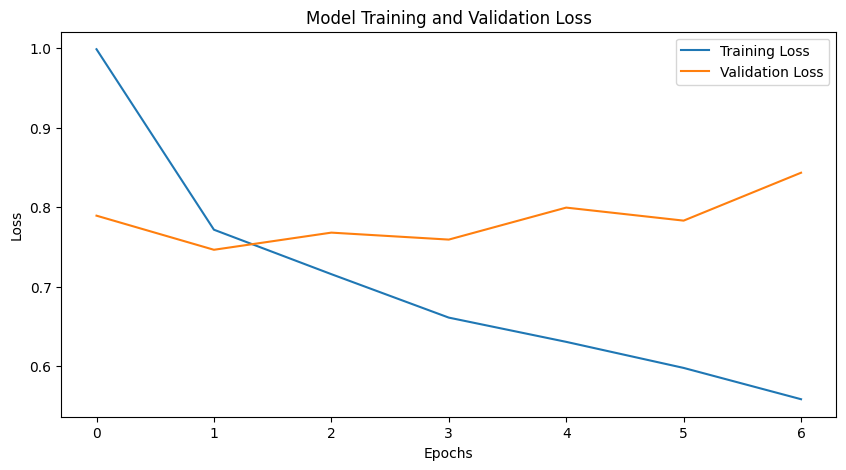

In [25]:
import matplotlib.pyplot as plt

# Assuming you have a history object from model.fit()
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [26]:
# Evaluate the model on the validation dataset

results = model.evaluate(x = val_feats_scaled, y = val_labels_one_hot , verbose=0)

# Print all results

print(results)

[0.7463451623916626, 0.9289173483848572, 0.6748324632644653, 0.6729404926300049, 0.8292250037193298]


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming val_reg is your validation dataset
# Extract true labels and convert from one-hot encoding to integer labels if necessary
y_true = val_labels

# Predict the classes with the best model on the validation data

y_pred = model.predict(val_feats_scaled)

y_pred_classes = np.argmax(y_pred, axis=1)  # Convert from probabilities to class labels

y_pred_classes = y_pred_classes + 1



136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step


In [37]:
# Compute the confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)
cm

array([[ 246,   34,   10,    0,    0,    0],
       [ 141,  754,  288,   11,    1,    0],
       [  15,  234, 1011,  302,    4,    0],
       [   1,    3,  152,  748,   85,    1],
       [   0,    0,    2,   85,  154,    5],
       [   0,    0,    0,    0,   33,    7]])

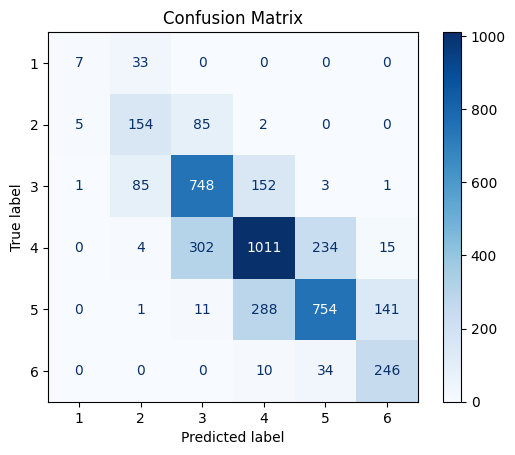

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, y_pred_classes, labels=sorted(val_labels.unique(), reverse=True))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(val_labels.unique(), reverse=False))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [39]:
print(sorted(val_labels.unique()))
print(sorted(pd.Series(y_pred_classes).unique()))

[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]


In [40]:
from sklearn.metrics import cohen_kappa_score

# Calculate the Quadratic Weighted Kappa

qwk_score = cohen_kappa_score(y_true, y_pred_classes, weights='quadratic')

print("Quadratic Weighted Kappa score:", qwk_score)

Quadratic Weighted Kappa score: 0.8389001601756878


In [41]:
model.save('best_classification_model.keras')

# Train on full unbalanced data

In [ ]:
print(full_train_feats_scaled.shape, full_train_labels_one_hot.shape)
print(sampled_train_feats_scaled.shape,sampled_train_labels_one_hot.shape)

In [ ]:
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

full_model = tuner.hypermodel.build(best_hps)
full_history = model.fit(full_train_feats_scaled, full_train_labels_one_hot, 
                    epochs=1000, batch_size=32, 
                    callbacks = call_backs, verbose=2, validation_data= (full_val_feats_scaled, full_val_labels_one_hot))

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a history object from model.fit()

plt.figure(figsize=(10, 5))
plt.plot(full_history.history['loss'], label='Training Loss')
plt.plot(full_history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate the model on the validation dataset

full_results = full_model.evaluate(x = full_val_feats_scaled, y = full_val_labels_one_hot , verbose=0)

# Print all results

print(results)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming val_reg is your validation dataset

# Extract true labels and convert from one-hot encoding to integer labels if necessary
full_y_true = np.argmax(full_val_labels_one_hot, axis=1)

if full_y_true.ndim > 1 and full_y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
    full_y_true = np.argmax(full_y_true, axis=1)

# Predict the classes with the best model on the validation data

full_y_pred = full_model.predict(full_val_feats_scaled)

full_y_pred_classes = np.argmax(full_y_pred, axis=1)  # Convert from probabilities to class labels

# Compute the confusion matrix
full_cm = confusion_matrix(full_y_true, full_y_pred_classes)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(full_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
full_model.save('full_best_classification_model.keras')

In [46]:
import shap
import numpy as np

# Instantiate a KernelExplainer
explainer = shap.KernelExplainer(model.predict, shap.sample(train_feats_scaled, 100))  # Using 100 samples for approximation

# Compute SHAP values for the validation set
shap_values = explainer.shap_values(val_feats_scaled)

# Visualizing the SHAP values
shap.summary_plot(shap_values, val_feats_scaled, feature_names=feature_cols)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step


  0%|          | 0/4327 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 5s 478us/step


  0%|          | 1/4327 [00:16<19:29:40, 16.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 5s 474us/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9688/9688 ━━━━━━━━━━━━━━━━━━━━ 5s 540us/step


  1%|          | 29/4327 [08:06<20:36:28, 17.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 5s 484us/step


  1%|          | 30/4327 [08:23<20:30:12, 17.18s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 5s 483us/step
